<a href="https://colab.research.google.com/github/hjiwoong/bigdata/blob/main/Visualization%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 환경설정

In [1]:
#구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

#드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt #그래프 그리는 모듈
import matplotlib.font_manager as fm #폰트 관리하는 모듈

#드라이브 내 폰트 경로
font_path = "/content/drive/MyDrive/KWU/bigdata/dataPreProcessing/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
mpl.rc('font',family = 'NanumGothic') #matplolib 기본 폰트로 설정
plt.rcParams['font.family'] = "NanumGothic"
plt.rcParams['font.sans-serif'] = ['NanumGothic', 'sans_serif']
plt.rcParams['axes.unicode_minus'] = False #마이너스(-) 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ",plt.rcParams['font.family']) #현재 적용된 폰트 이름 출력

Mounted at /content/drive
현재 폰트:  ['NanumGothic']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#타이타닉 데이터 로드
titanic = pd.read_csv('/content/drive/MyDrive/KWU/bigdata/dataPreProcessing/train.csv')
print(titanic.shape)
titanic.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic_clean = titanic.copy()

#Cabin 열 삭제
titanic_clean = titanic_clean.drop(columns=['Cabin'])

#Age 결측치 처리
titanic_clean['Age'] = titanic_clean.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

#Embarked 결측치 처리
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])

#최종 결측치 현황 확인
print("전처리 후 결측치: ")
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum()>0])

print(f"\n 원본 shape: {titanic.shape}")
print(f"전처리 후 shape: {titanic_clean.shape}")

전처리 후 결측치: 
Series([], dtype: int64)

 원본 shape: (891, 12)
전처리 후 shape: (891, 11)


### 1.matplotlib으로 그래프 그리기

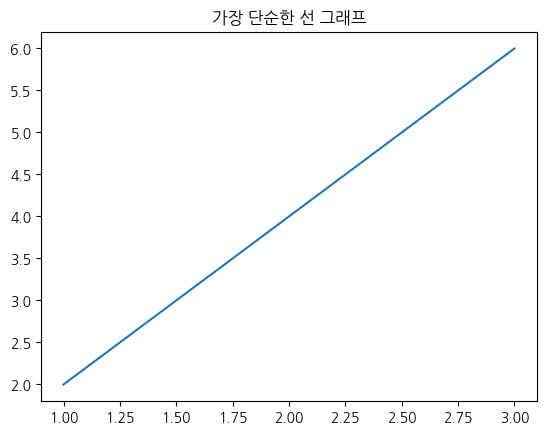

In [4]:
#plt.plot(x좌표 리스트, y좌표 리스트) 선 그래프
plt.plot([1,2,3],[2,4,6])
plt.title('가장 단순한 선 그래프')
plt.show()

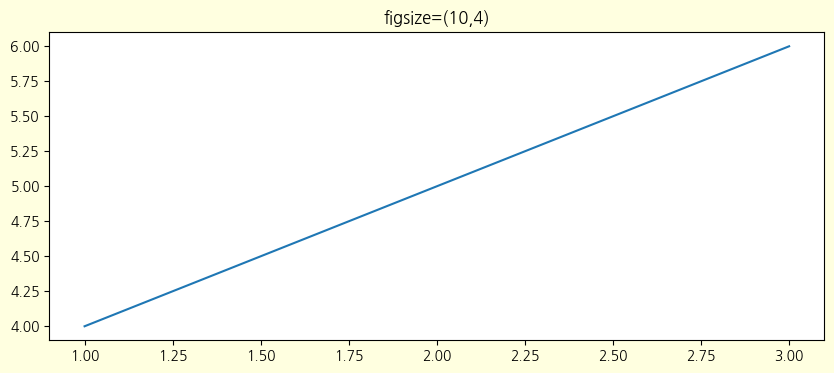

In [5]:
#Figure: 전체 도화지(크기, 배경색 설정)
#Axes: 실제 그래프가 그려지는 영역(축, 제목, 그래프)

plt.figure(figsize=(10,4), facecolor='lightyellow') #가로10, 세로4인치 #facecolor=배경색 설정
plt.plot([1,2,3],[4,5,6])
plt.title('figsize=(10,4)')
plt.show()

In [6]:
#Axes 객체 생성
ax = plt.axes()
print('ax 타입:',type(ax))
plt.close()

ax 타입: <class 'matplotlib.axes._axes.Axes'>


In [7]:
#Figure + Axes 동시 생성
fig, ax = plt.subplots()
print('fig 타입:', type(fig))
print('ax 타입:', type(ax))
plt.close()

fig 타입: <class 'matplotlib.figure.Figure'>
ax 타입: <class 'matplotlib.axes._axes.Axes'>


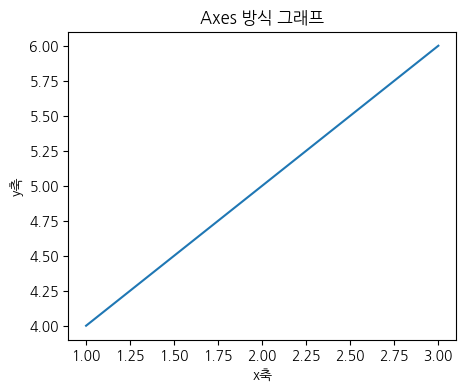

In [8]:
#Axes 객체 방식으로 그래프 그리기
#plt.plot() -> ax.plot()
#plt.title() -> ax.set_title()

fig, ax = plt.subplots(figsize=(5,4))
ax.plot([1,2,3],[4,5,6])
ax.set_title('Axes 방식 그래프')
ax.set_xlabel('x축')
ax.set_ylabel('y축')
plt.show()

#plt방식 vs Axes 방식 비교
#plt.plot() ↔ ax.plot()
#plt.xlabel() ↔ ax.set_xlabel()
#plt.ylabel() ↔ ax.set_ylabel()
#plt.title() ↔ ax.set_title()
#plt.legend() ↔ ax.legend()

In [9]:
#여러 개의 subplot 생성
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3))

print('ax 타입:', type(ax))
print('ax[0] 타입:', type(ax[0]))
print('ax[1] 타입:', type(ax[1]))
plt.close()

ax 타입: <class 'numpy.ndarray'>
ax[0] 타입: <class 'matplotlib.axes._axes.Axes'>
ax[1] 타입: <class 'matplotlib.axes._axes.Axes'>


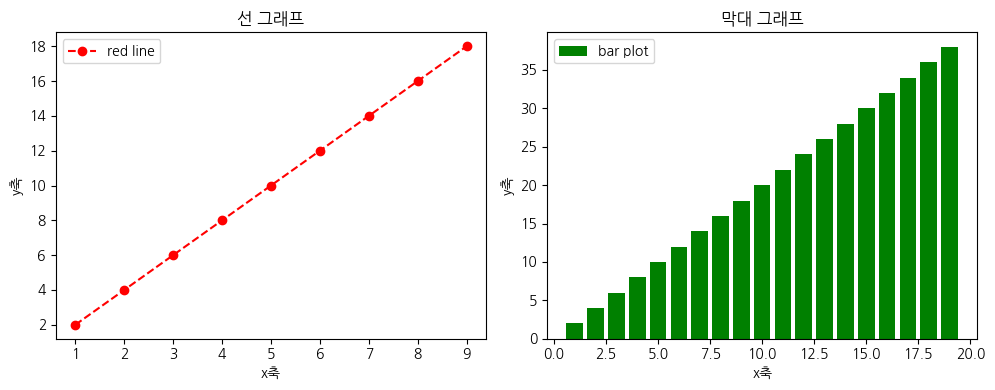

In [10]:
#1 × 2 subplot
x1=np.arange(1, 10)
x2=np.arange(1, 20)
y1= 2 * x1
y2= 2 * x2

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
ax[0].plot(x1, y1, color='red', marker='o', linestyle='dashed', label='red line')
ax[0].set_xlabel('x축')
ax[0].set_ylabel('y축')
ax[0].legend()
ax[0].set_title('선 그래프')

ax[1].bar(x2, y2, color='green', label='bar plot')
ax[1].set_xlabel('x축')
ax[1].set_ylabel('y축')
ax[1].legend()
ax[1].set_title('막대 그래프')

plt.tight_layout() #여러 subplot 간격 자동 조정
plt.show()

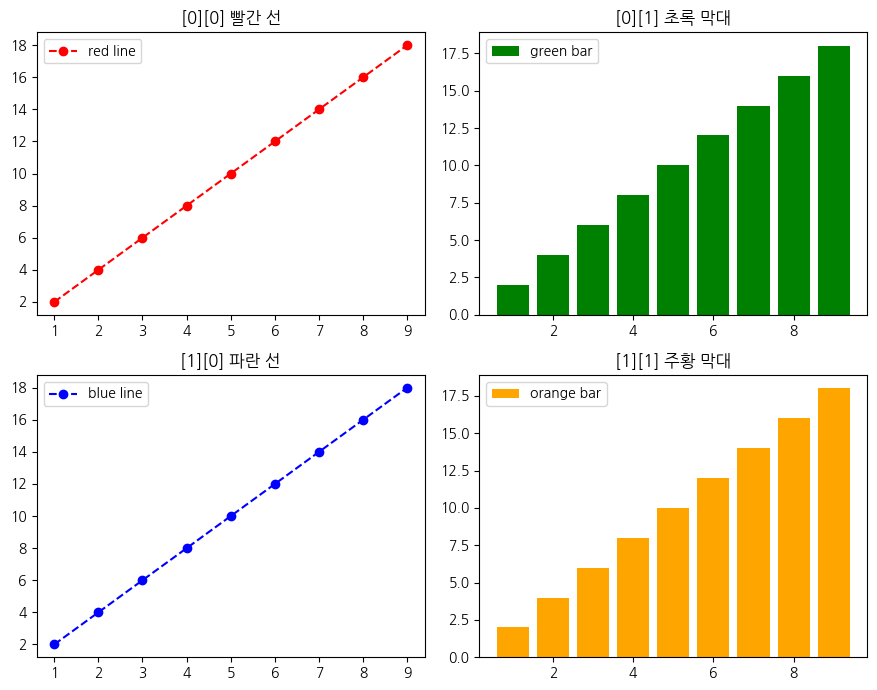

In [11]:
# 2 × 2 subplot: 2D 이차원 배열로 반환, ax[행][열]로 접근
fig, ax=plt.subplots(nrows=2, ncols=2, figsize=(9,7))

x1=np.arange(1, 10)
x2=np.arange(1, 20)
y1= 2 * x1
y2= 2 * x2

#ax[0][0]: 1행 1열(왼쪽 상단)
ax[0][0].plot(x1, y1, color='red', marker='o', linestyle='dashed',label='red line')
ax[0][0].set_title('[0][0] 빨간 선')
ax[0][0].legend()

#ax[0][1]: 1행 2열(오른쪽 상단)
ax[0][1].bar(x1, y1, color='green', label='green bar')
ax[0][1].set_title('[0][1] 초록 막대')
ax[0][1].legend()

#ax[1][0]: 2행 1열(왼쪽 하단)
ax[1][0].plot(x1, y1, color='blue', marker='o', linestyle='dashed',label='blue line')
ax[1][0].set_title('[1][0] 파란 선')
ax[1][0].legend()

#ax[1][1]: 2행 2열(오른쪽 하단)
ax[1][1].bar(x1, y1, color='orange', label='orange bar')
ax[1][1].set_title('[1][1] 주황 막대')
ax[1][1].legend()

plt.tight_layout()
plt.show()

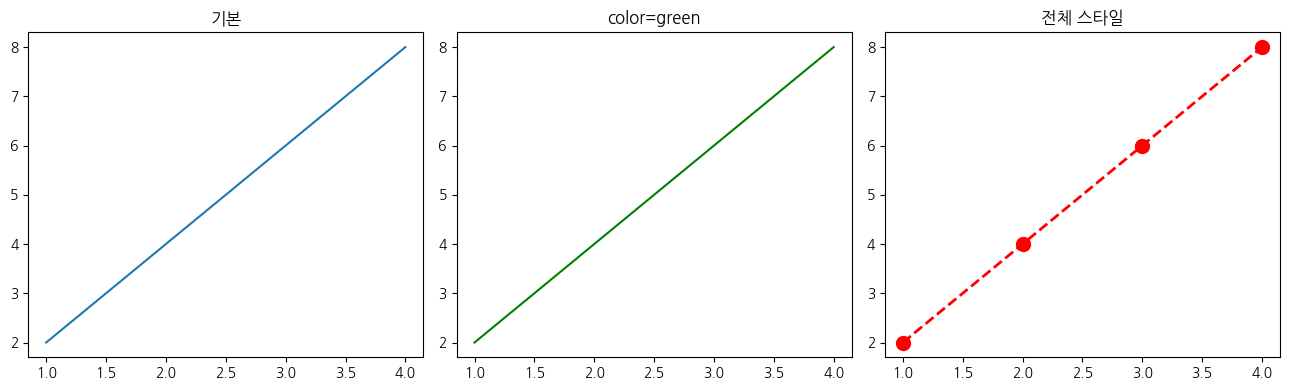

In [12]:
#선 그래프 옵션 - 색상, 마커, 축, 범례

x_val = [1,2,3,4]
y_val = [2,4,6,8]

fig, axes=plt.subplots(1,3,figsize=(13,4))

axes[0].plot(x_val, y_val)
axes[0].set_title('기본')

axes[1].plot(x_val, y_val, color='green')
axes[1].set_title('color=green')

axes[2].plot(x_val, y_val, color='red', marker='o', linestyle='dashed', linewidth=2, markersize=10)
axes[2].set_title('전체 스타일')

plt.tight_layout()
plt.show()

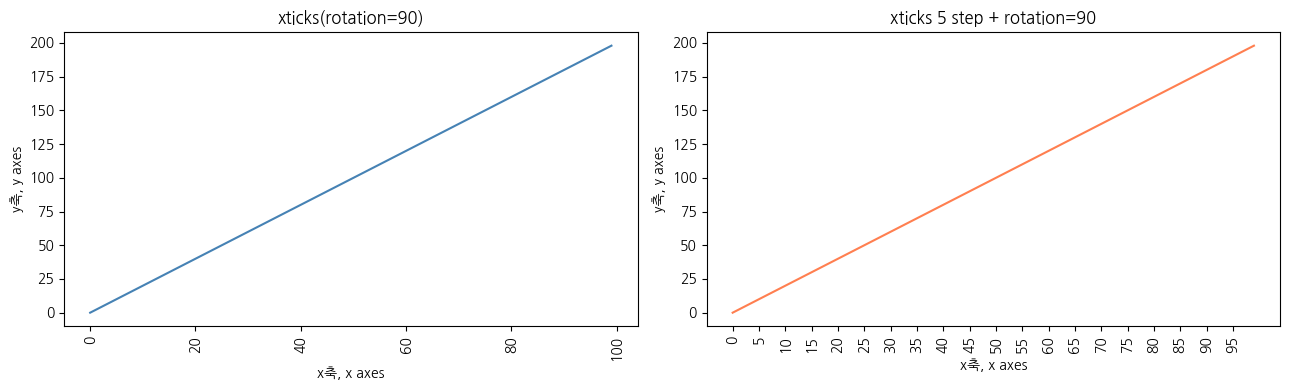

In [13]:
#x축 틱(눈금) 회전
x_value = np.arange(0,100)
y_value = 2 * x_value

fig, axes = plt.subplots(1,2,figsize=(13,4))
axes[0].plot(x_value, y_value, color='steelblue')
axes[0].set_xlabel('x축, x axes')
axes[0].set_ylabel('y축, y axes')
axes[0].set_title('xticks(rotation=90)')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(x_value, y_value, color='coral')
axes[1].set_xlabel('x축, x axes')
axes[1].set_ylabel('y축, y axes')
axes[1].set_title('xticks 5 step + rotation=90')
axes[1].set_xticks(np.arange(0, 100, 5)) #0부터99까지 5간격으로 표시하고 90도 회전
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

#plt 방식: plt.xticks(rotation=90)
#axes 방식: ax.tick_params(axis=x, rotation=90)

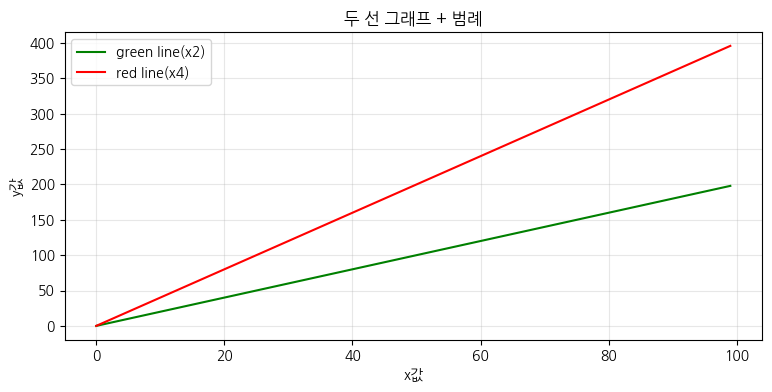

In [14]:
#범례(legend) 설정
x_value = np.arange(0, 100)
y1 = 2 * x_value
y2 = 4 * x_value

plt.figure(figsize=(9,4))

plt.plot(x_value, y1, color='green', label='green line(x2)')
plt.plot(x_value, y2, color='red', label='red line(x4)')

plt.xlabel('x값')
plt.ylabel('y값')
plt.title('두 선 그래프 + 범례')

#legend(): label이 설정된 그래프들을 자동으로 범례에 추가
plt.legend(loc = 'upper left')

plt.grid(True, alpha=0.3) #격자 추가
plt.show()

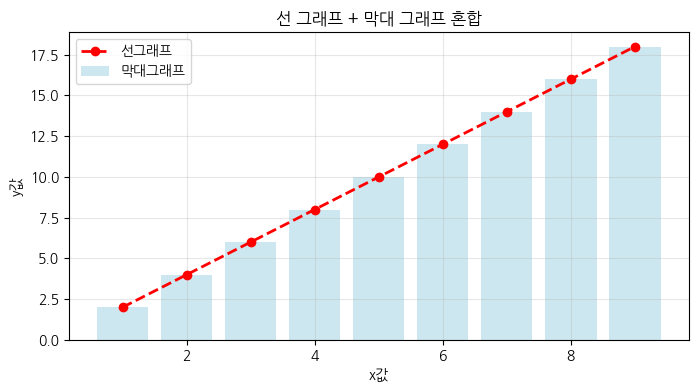

In [15]:
x=np.arange(1,10)
y=2*x

fig, ax = plt.subplots(figsize=(8,4))

#같은 ax에 두 종류의 그래프 동시에 그리기
ax.plot(x,y,color='red', marker='o',linestyle='dashed', label='선그래프', linewidth=2)
ax.bar(x,y,color='lightblue', alpha=0.6, label='막대그래프')

ax.set_xlabel('x값')
ax.set_ylabel('y값')
ax.set_title('선 그래프 + 막대 그래프 혼합')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 2.seaborn으로 그래프 그리기
- matplotlib : axes[0][0].hist(data)
- seaborn : sns.histplot(x='column', data=df, ax=axes[0][0])

In [16]:
#타이타닉 데이터 확인
print(titanic_clean.shape)
print(titanic_clean.columns.tolist())
display(titanic_clean.tail())

(891, 11)
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.45,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q


- 이산형: 셀 수 있는 (countable)값(정수 형태)
- 연속형: 측정 가능한 범위 내에서 어떤 값이든 가질 수 있는 (실수 형태)

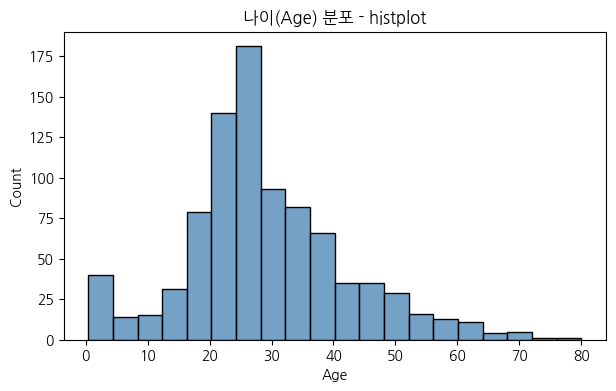

In [17]:
#히스토그램(Histogram)
#연속형 데이터의 구간별 도수 분포 - 데이터가 어떻게 퍼져 있는지 확인
plt.figure(figsize=(7, 4))

sns.histplot(titanic_clean['Age'], bins=20, color='steelblue')
plt.title('나이(Age) 분포 - histplot')
plt.show()

#sns.histplot()의 첫 번째 인자: Series 또는 (x=컬럼명, data=df)
#bins: 막대 개수(많을수록 세밀)
#DataFrame 컬럼명을 자동으로 인식해 xlabel 설정

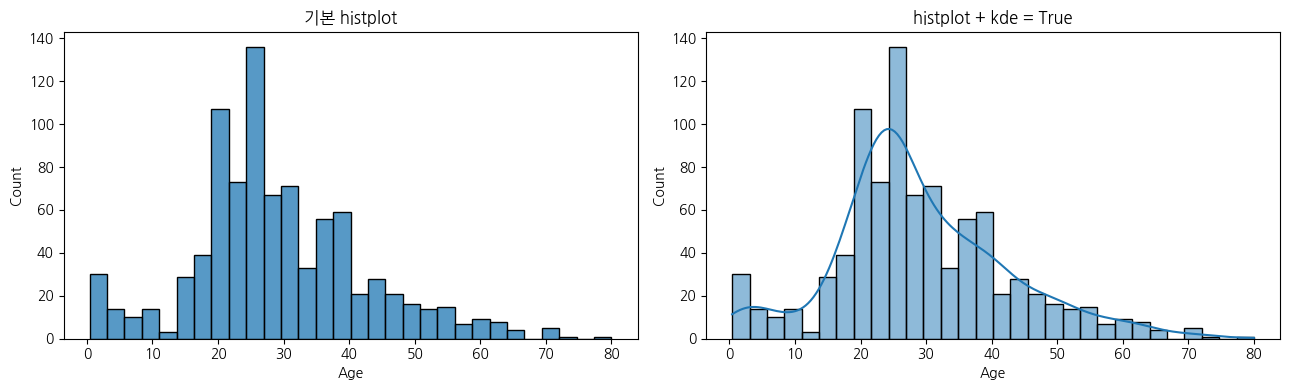

In [18]:
#kde=True: 커널 밀도 추정 곡선 추가
#kde: Kernel Density Estimation - 부드러운 분포 곡선
fig, axes = plt.subplots(1,2,figsize=(13,4))

sns.histplot(x="Age", data=titanic_clean, bins=30, ax=axes[0])
axes[0].set_title('기본 histplot')

sns.histplot(x="Age", data=titanic_clean, bins=30, kde=True, ax=axes[1])
axes[1].set_title('histplot + kde = True')

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

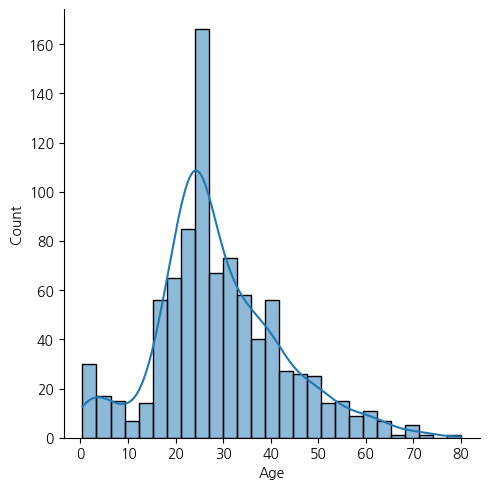

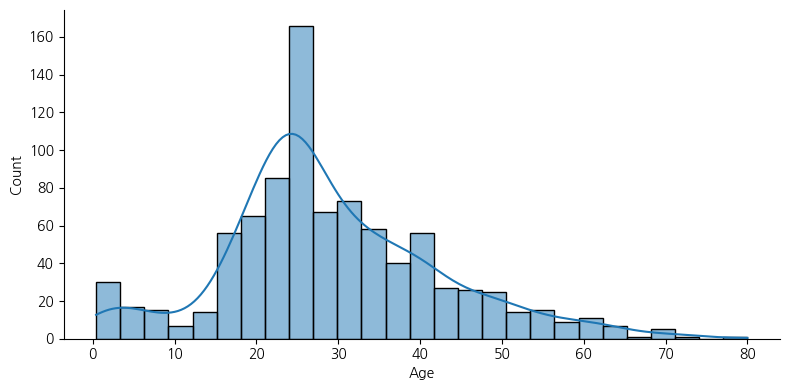

In [19]:
#올바른 크기 설정 방법: height, aspect 파라미터
plt.figure(figsize=(8,4)) #이 설정은  displot에 무시됨, 기본 크기로 출력
sns.displot(x="Age", data=titanic_clean, kde=True)
plt.show()

sns.displot(titanic_clean["Age"], kde=True, height=4, aspect=2) #가로 = height × aspect
plt.show()

#histplot(Axes레벨): plt.figure() 적용 -> ax=배치 가능
#displot(Figure레벨): plt.figure() 무시 -> height.aspect 사용

/tmp/ipykernel_2196/4259656834.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=titanic_clean, ax=axes[1], palette=['#FF5722','#4CAF50'])
/tmp/ipykernel_2196/4259656834.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['사망(0)','생존(1)'])
/tmp/ipykernel_2196/4259656834.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex',data=titanic_clean, ax=axes[2], palette='pastel')


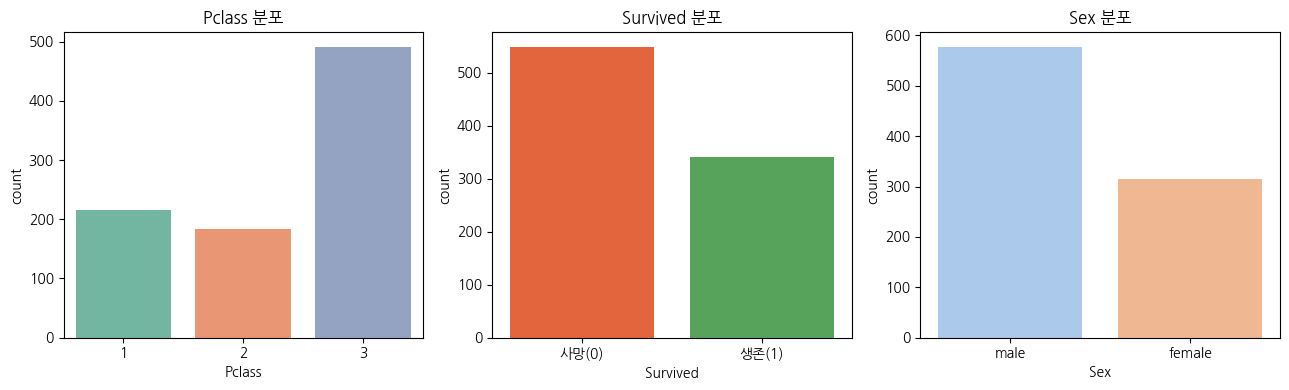

In [20]:
#카운트 플롯(Count Plot)
#범주형 변수의 값별 건수 시각화 - x축: 카테고리, y축: 자동 계산된 건수
fig, axes = plt.subplots(1,3,figsize=(13,4))

#countplot: x축에 범주형 컬럼을 지정하면 y축(건수)을 자동 계산
#Pclass별 승객 수
sns.countplot(x='Pclass',data=titanic_clean, ax=axes[0], palette='Set2', hue='Pclass', legend=False) #palette: 색상 팔레트
axes[0].set_title('Pclass 분포')

#생존 여부별 건수
sns.countplot(x='Survived',data=titanic_clean, ax=axes[1], palette=['#FF5722','#4CAF50'])
axes[1].set_title('Survived 분포')
axes[1].set_xticklabels(['사망(0)','생존(1)'])

#성별 건수
sns.countplot(x='Sex',data=titanic_clean, ax=axes[2], palette='pastel')
axes[2].set_title('Sex 분포')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2196/1447224327.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass',y='Survived',data=titanic_clean, ci=None, estimator=sum, palette=['#349808','#2ECC71','#E74C3C'], ax=axes[2])
/tmp/ipykernel_2196/1447224327.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass',y='Survived',data=titanic_clean, ci=None, estimator=sum, palette=['#349808','#2ECC71','#E74C3C'], ax=axes[2])


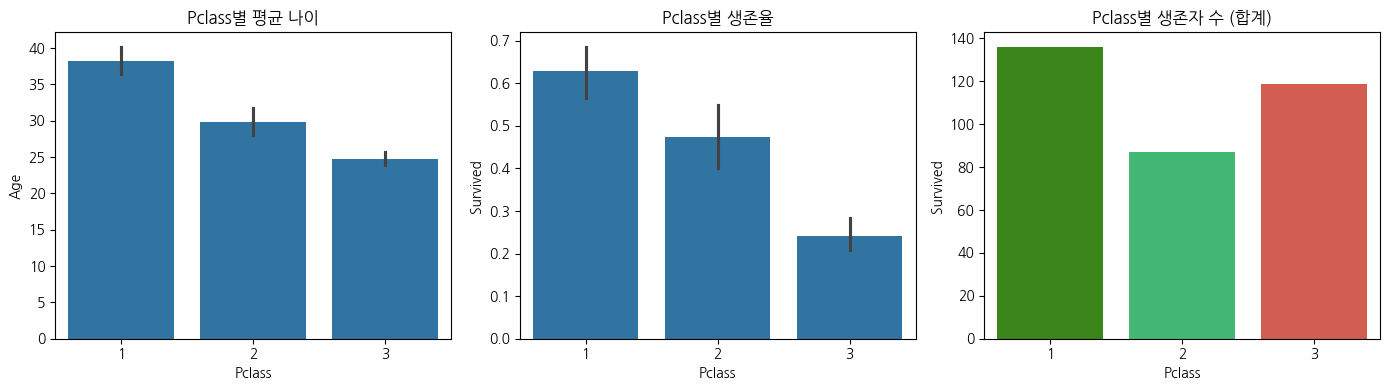

In [21]:
#바 플롯(Bar Plot) - 막대 그래프
#x축: 범주형, y축: 연속형의 집계(기본=평균)
fig, axes = plt.subplots(1,3,figsize=(14,4))

#Pclass별 평균 나이
sns.barplot(x='Pclass',y='Age',data=titanic_clean, ax=axes[0])
axes[0].set_title('Pclass별 평균 나이')

#Pcalss별 생존율 (Survived의 평균 = 생존율)
sns.barplot(x='Pclass',y='Survived',data=titanic_clean, ax=axes[1])
axes[1].set_title('Pclass별 생존율')

#ci=None: 신뢰구간 제거, estimator=sum: 평균 대신 합계 표시
sns.barplot(x='Pclass',y='Survived',data=titanic_clean, ci=None, estimator=sum, palette=['#349808','#2ECC71','#E74C3C'], ax=axes[2])
axes[2].set_title('Pclass별 생존자 수 (합계)')

plt.tight_layout()
plt.show()

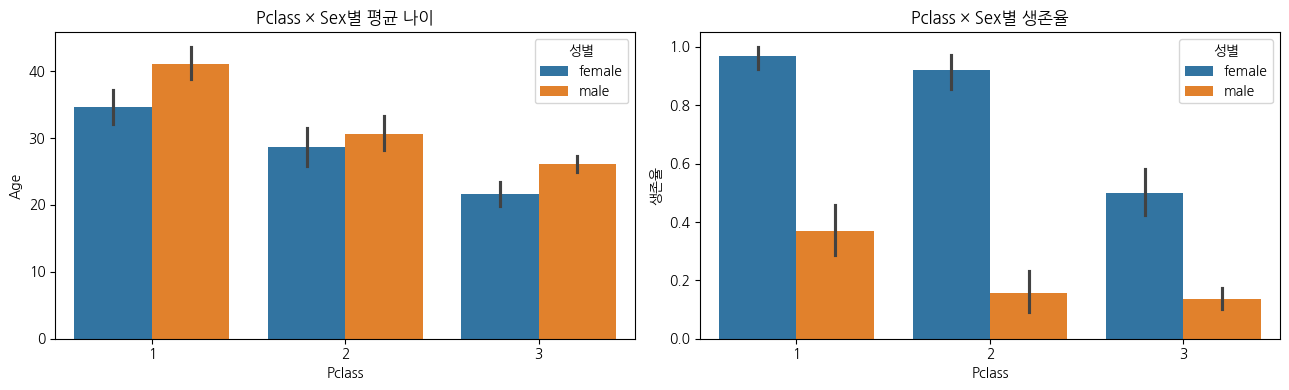

In [22]:
#hue 인자: 추가 범주로 세분화
#hue='Sex': 각 Pclass 안에서 Male/Female을 색상으로 구분

fig, axes = plt.subplots(1,2,figsize=(13,4))

#Pclass × Sex별 평균 나이
sns.barplot(x='Pclass', y='Age', hue='Sex', data=titanic_clean, ax=axes[0])
axes[0].set_title('Pclass × Sex별 평균 나이')
axes[0].legend(title='성별')

#Pclass × Sex별 생존율
sns.barplot(x='Pclass',y='Survived', hue='Sex', data=titanic_clean, ax=axes[1])
axes[1].set_title('Pclass × Sex별 생존율')
axes[1].legend(title='성별')
axes[1].set_ylabel('생존율')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2196/3661968677.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Age", data=titanic_clean, ax=axes[1], palette="Set3")


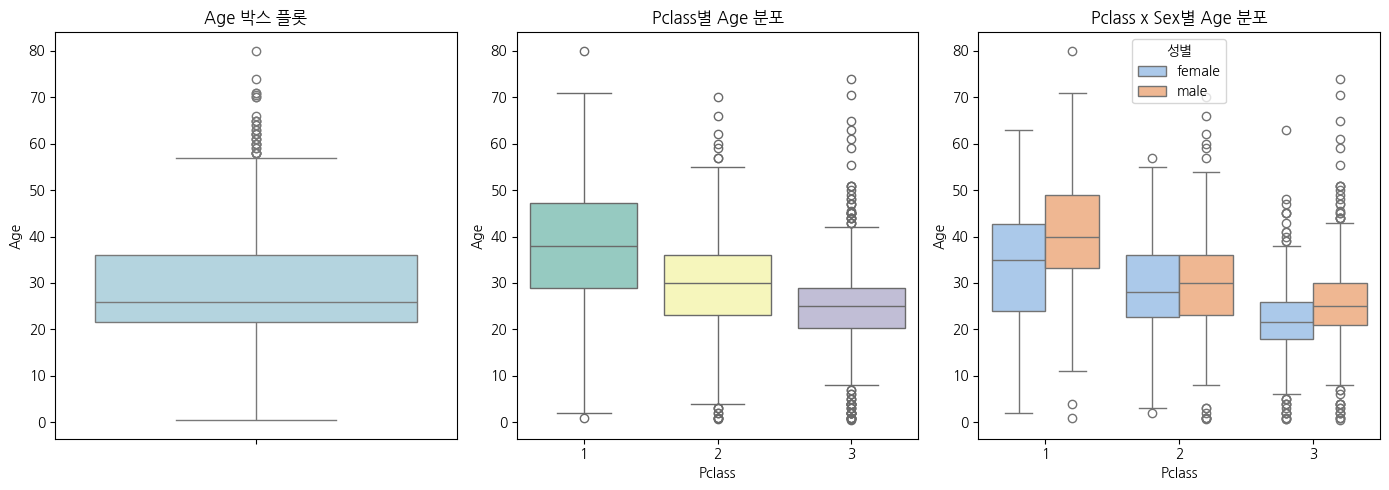

In [23]:
#박스플롯(Box Plot)
#데이터의 4분위수를 박스로 표현 - 중앙값, 분포, 이상치 한눈에 파악
fig, axes = plt.subplots(1,3,figsize=(14,5))

#단일 컬럼 박스 플롯
sns.boxplot(y='Age', data=titanic_clean, ax=axes[0], color='lightblue')
axes[0].set_title('Age 박스 플롯')

#Pclass별 Age박스 플롯
#x축: 범주형 / y축: 연속형 -> 범주별 분포 비교 가능
sns.boxplot(x="Pclass", y="Age", data=titanic_clean, ax=axes[1], palette="Set3")
axes[1].set_title('Pclass별 Age 분포')

#hue='Sex':Pclass × Sex별 박스 플롯(6개 박스)
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic_clean, ax=axes[2], palette='pastel')
axes[2].set_title('Pclass x Sex별 Age 분포')
axes[2].legend(title='성별')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2196/4131631962.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Pclass", y="Age", data=titanic_clean, ax=axes[1], palette="muted")


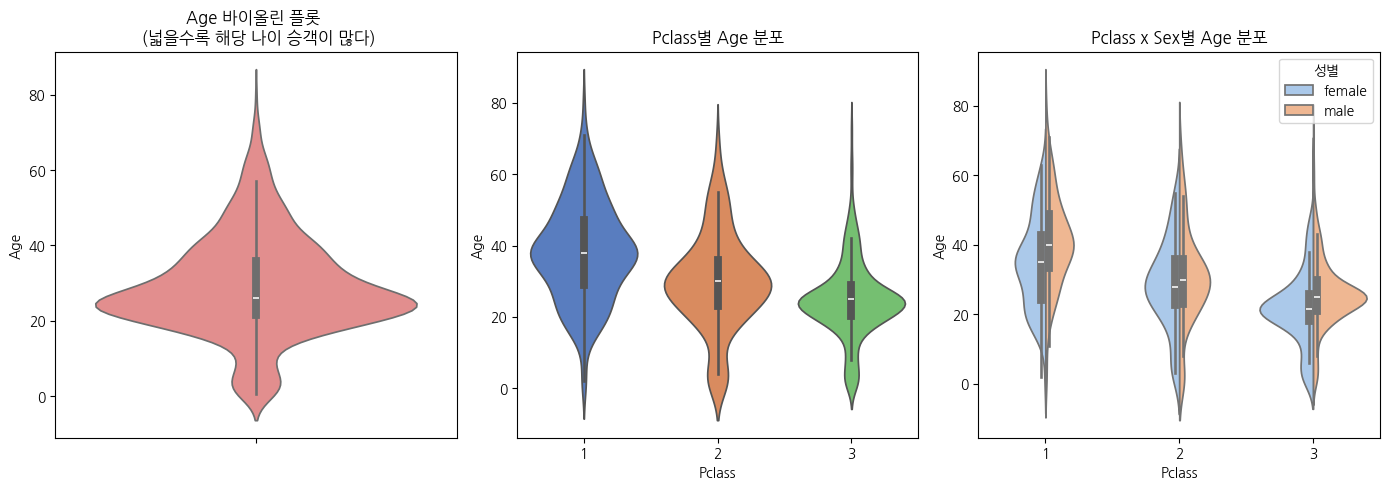

In [24]:
#바이올린 플롯(Violin Plot)
#박스 플롯 + 확률 밀도 곡선 - 데이터 분포 형태를 더 자세히 파악
fig, axes = plt.subplots(1,3,figsize=(14,5))

#단일 컬럼 바이올린 플롯
sns.violinplot(y='Age', data=titanic_clean, ax=axes[0], color='lightcoral')
axes[0].set_title('Age 바이올린 플롯 \n (넓을수록 해당 나이 승객이 많다)')

#Pclass별 Age 바이올린 플롯
sns.violinplot(x="Pclass", y="Age", data=titanic_clean, ax=axes[1], palette="muted")
axes[1].set_title('Pclass별 Age 분포')

#hue='Sex': split=True로 좌우를 성별로 분할
sns.violinplot(x='Pclass', y='Age', hue='Sex', data=titanic_clean, ax=axes[2], split=True, palette='pastel')
axes[2].set_title('Pclass x Sex별 Age 분포')
axes[2].legend(title='성별')

plt.tight_layout()
plt.show()

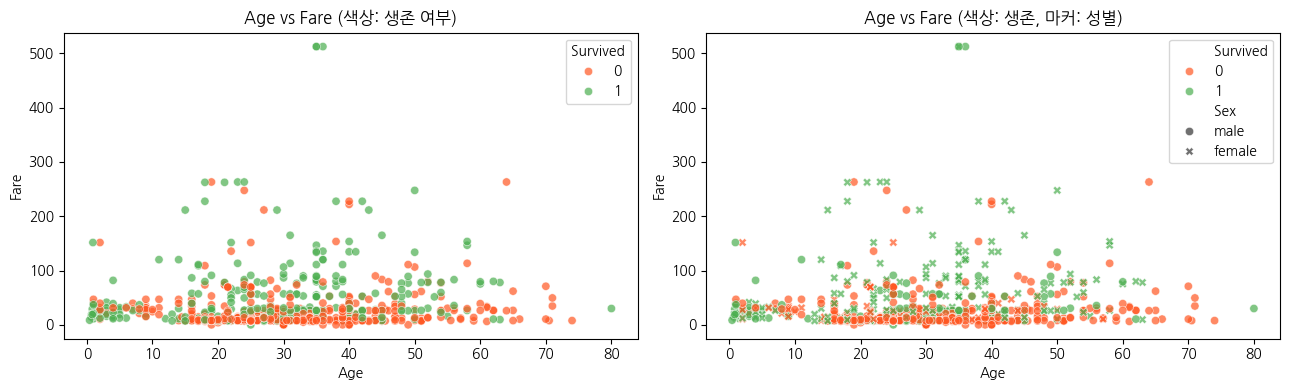

In [25]:
#산점도 (Scatter Plot)
#X와 Y 두 연속형 변수 간의 관계 시각화
fig, axes = plt.subplots(1,2,figsize=(13,4))

#hue: 범주형 컬럼으로 색상 구분
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=titanic_clean, ax=axes[0], palette=['#FF5722', '#4CAF50'], alpha=0.7)
axes[0].set_title('Age vs Fare (색상: 생존 여부)')
#axes[0].legend(title='생존', labels=['사망','생존'])

#hue + style: 색상과 마커 모양 모두 구분
sns.scatterplot(x='Age', y='Fare', hue='Survived', style='Sex', data=titanic_clean, ax=axes[1], palette=['#FF5722','#4CAF50'], alpha=0.7)
axes[1].set_title('Age vs Fare (색상: 생존, 마커: 성별)')

plt.tight_layout()
plt.show()

In [26]:
#상관 히트맵(Correlation Heatmap)
#컬럼 간 피어슨(Pearson) 상관계수(-1 ~ 1)를 색상 강도로 표현
corr = titanic_clean.select_dtypes(include=np.number).corr() #숫자로 분류될 수 있는 모든 컬럼들만 필터링하여 새로운 DataFrame을 반환
print('상관계수 행렬(일부):')
print(corr.round(2))

상관계수 행렬(일부):
             PassengerId  Survived  Pclass   Age  SibSp  Parch  Fare
PassengerId         1.00     -0.01   -0.04  0.04  -0.06  -0.00  0.01
Survived           -0.01      1.00   -0.34 -0.06  -0.04   0.08  0.26
Pclass             -0.04     -0.34    1.00 -0.41   0.08   0.02 -0.55
Age                 0.04     -0.06   -0.41  1.00  -0.25  -0.18  0.12
SibSp              -0.06     -0.04    0.08 -0.25   1.00   0.41  0.16
Parch              -0.00      0.08    0.02 -0.18   0.41   1.00  0.22
Fare                0.01      0.26   -0.55  0.12   0.16   0.22  1.00


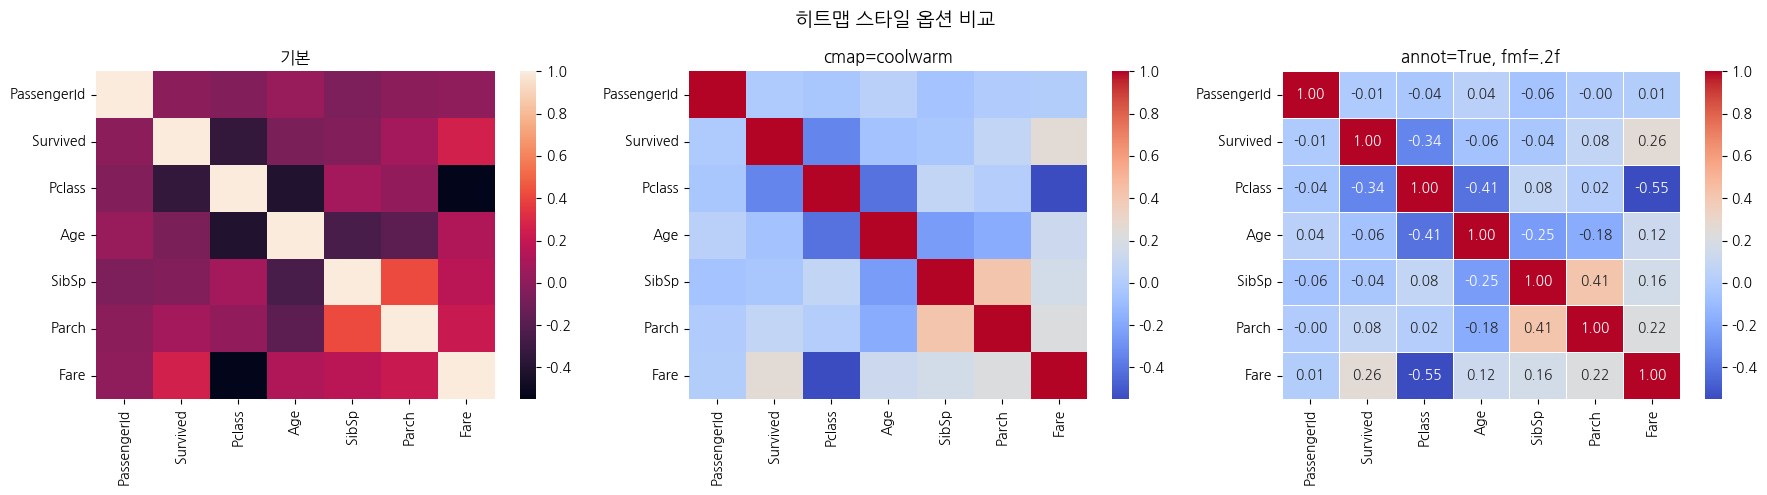

In [27]:
#히트맵 스타일 옵션 비교
fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle('히트맵 스타일 옵션 비교', fontsize=14, fontweight='bold')

# 1.기본(default 색상맵)
sns.heatmap(corr, ax=axes[0])
axes[0].set_title('기본')

# 2.cmap 변경: 'rocket','Blues','coolwarm','RdYlGn' 등
sns.heatmap(corr, cmap='coolwarm', ax=axes[1])
axes[1].set_title('cmap=coolwarm')

# 3.annot=True: 각 셀에 수치 표시
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', cbar=True, linewidths=.5, ax=axes[2]) #cbar=범례
axes[2].set_title('annot=True, fmf=.2f')

plt.tight_layout()
plt.show()

### subplots를 이용한 시본 그래프 시각화

/tmp/ipykernel_2196/1255315114.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=titanic_clean, ax=axes[idx], palette='Set2')
/tmp/ipykernel_2196/1255315114.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=titanic_clean, ax=axes[idx], palette='Set2')
/tmp/ipykernel_2196/1255315114.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=titanic_clean, ax=axes[idx], palette='Set2')
/tmp/ipykernel_2196/1255315114.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

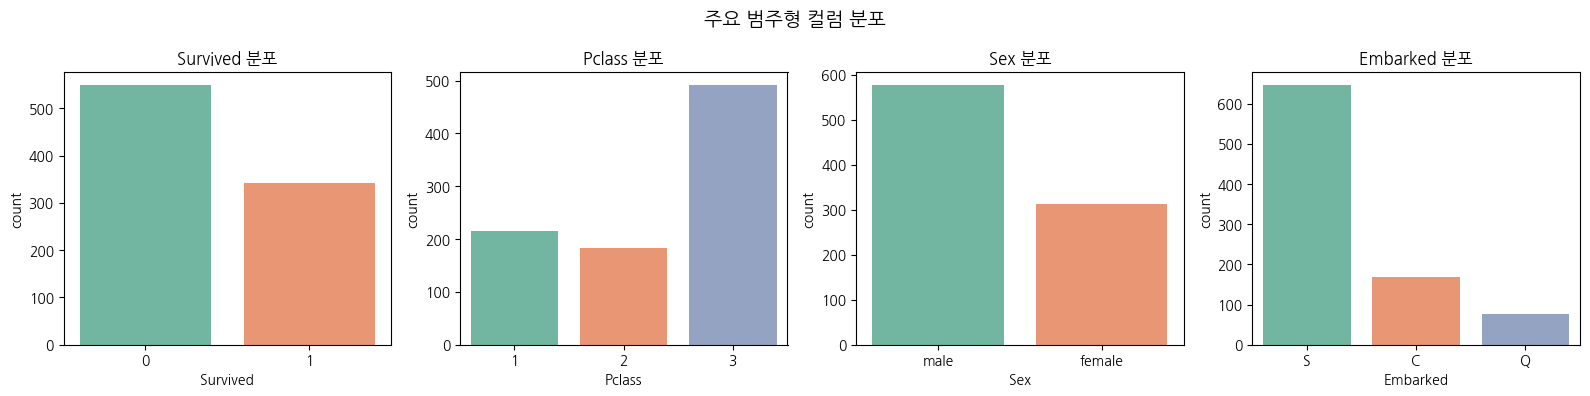

In [29]:
#범주형: 카테고리
#이산형 컬럼의 건수를 한번에 시각화
cat_columns = ['Survived', 'Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(16,4))
fig.suptitle('주요 범주형 컬럼 분포', fontsize=14, fontweight='bold')

for idx, col in enumerate(cat_columns):
  sns.countplot(x=col, data=titanic_clean, ax=axes[idx], palette='Set2')
  axes[idx].set_title(f'{col} 분포')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2196/1793112576.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='Survived', data=titanic_clean, ax=axes[idx], palette='Set1', ci=None)
/tmp/ipykernel_2196/1793112576.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Survived', data=titanic_clean, ax=axes[idx], palette='Set1', ci=None)
/tmp/ipykernel_2196/1793112576.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='Survived', data=titanic_clean, ax=axes[idx], palette='Set1', ci=None)
/tmp/ipykernel_2196/1793112576.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=co

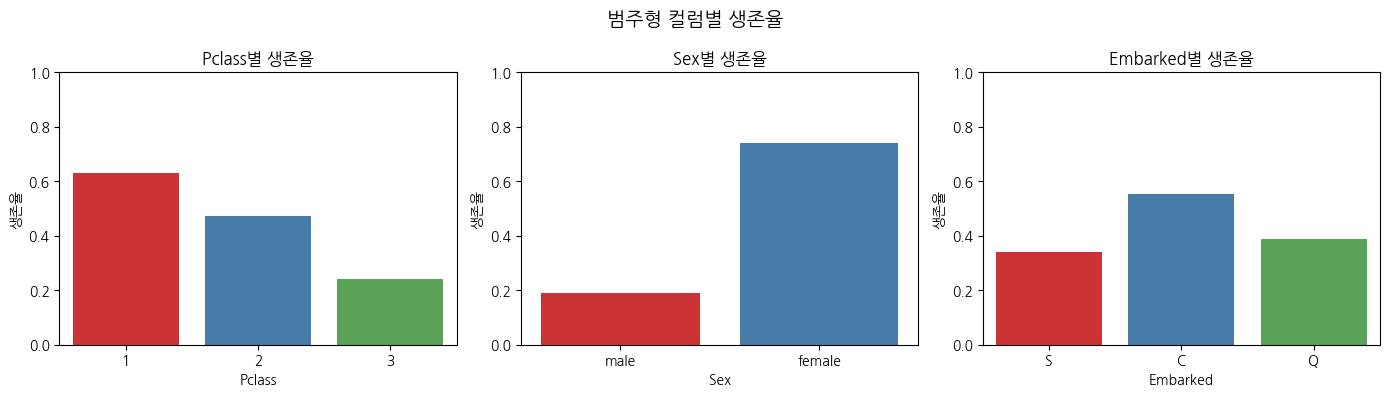

In [36]:
#범주형 컬럼별 생존율 시각화
cat_columns = ['Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14,4))
fig.suptitle('범주형 컬럼별 생존율', fontsize=14, fontweight='bold')

for idx, col in enumerate(cat_columns):
  sns.barplot(x=col, y='Survived', data=titanic_clean, ax=axes[idx], palette='Set1', ci=None)
  axes[idx].set_title(f'{col}별 생존율')
  axes[idx].set_ylabel('생존율')
  axes[idx].set_ylim(0,1) #y축 범위 0~1로 고정

plt.tight_layout()
plt.show()

/tmp/ipykernel_2196/3690248013.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Survived', y=col, data=titanic_clean, ax=axes[0], palette=['#FF8A80','#80D8FF'])
/tmp/ipykernel_2196/3690248013.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['사망(0)','생존(1)'])


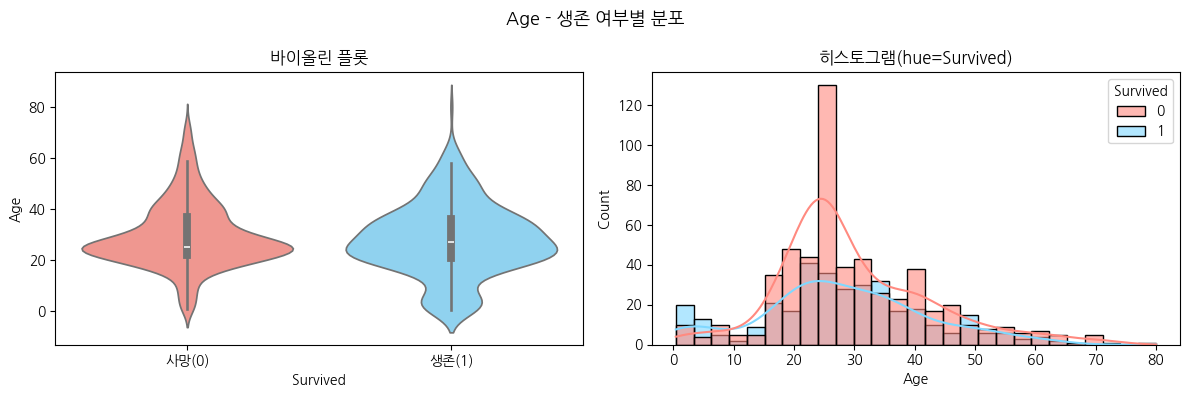

/tmp/ipykernel_2196/3690248013.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Survived', y=col, data=titanic_clean, ax=axes[0], palette=['#FF8A80','#80D8FF'])
/tmp/ipykernel_2196/3690248013.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['사망(0)','생존(1)'])


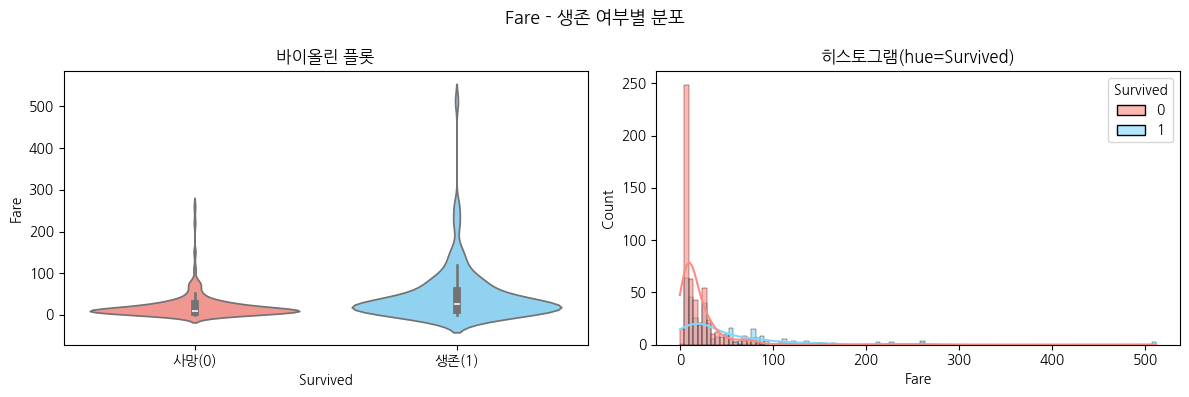

In [38]:
#연속형 컬럼: 바이올린 플롯 + 히스토그램 동시 시각화
cont_columns = ['Age','Fare']

for col in cont_columns:
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
  fig.suptitle(f'{col} - 생존 여부별 분포', fontsize=13, fontweight='bold')

  sns.violinplot(x='Survived', y=col, data=titanic_clean, ax=axes[0], palette=['#FF8A80','#80D8FF'])
  axes[0].set_title(f'바이올린 플롯')
  axes[0].set_xticklabels(['사망(0)','생존(1)'])

  sns.histplot(x=col, data=titanic_clean, kde=True, hue='Survived', ax=axes[1], palette=['#FF8A80','#80D8FF'], alpha=0.6)
  axes[1].set_title(f'히스토그램(hue=Survived)')

  plt.tight_layout()
  plt.show()

/tmp/ipykernel_2196/2934633079.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=titanic_clean, ax=ax1, palette=['#FF5722','#4CAF50'])
/tmp/ipykernel_2196/2934633079.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['사망(0)','생존(1)'])
/tmp/ipykernel_2196/2934633079.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=titanic_clean, ax=ax2, palette='Set2')
/tmp/ipykernel_2196/2934633079.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

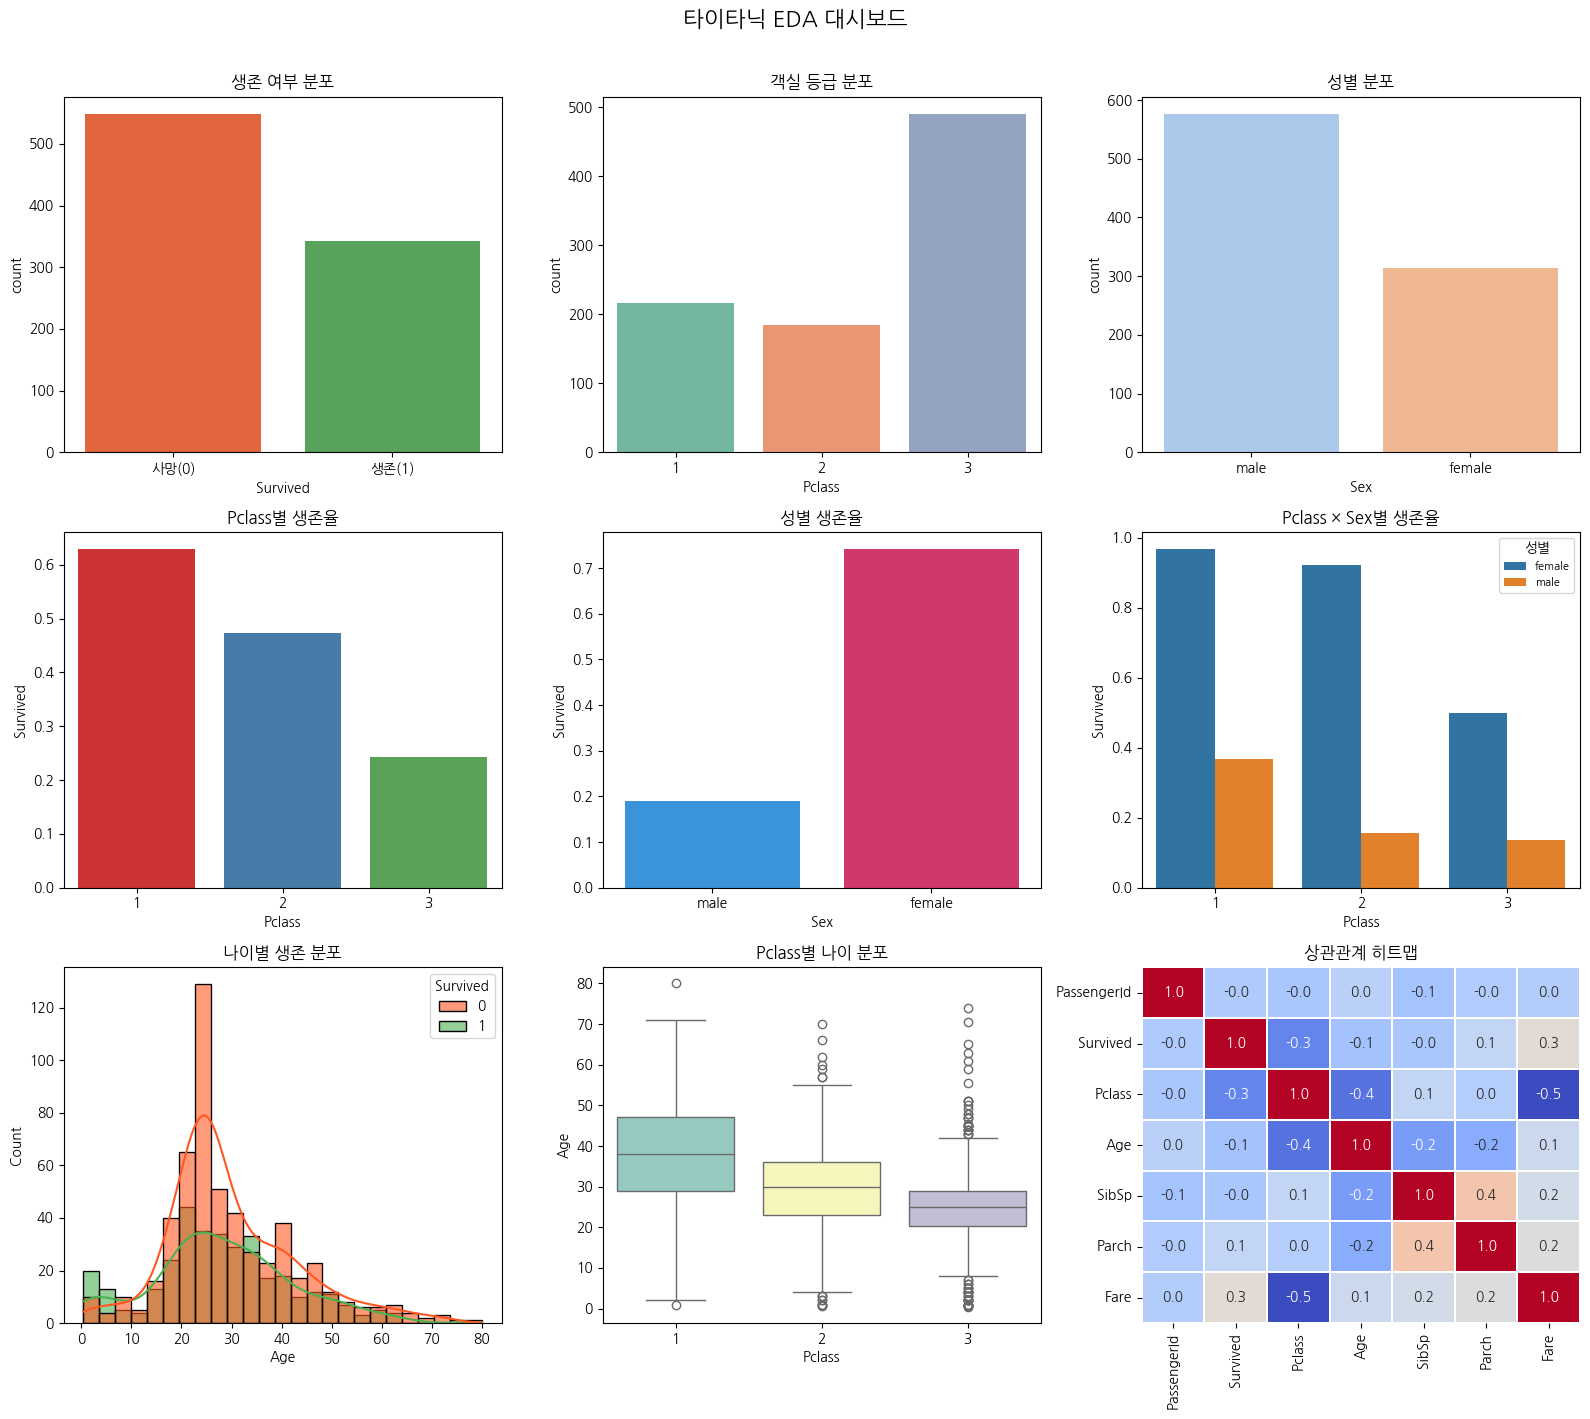

In [28]:
#타이타닉 EDA 대시보드
fig=plt.figure(figsize=(16,14))
fig.suptitle('타이타닉 EDA 대시보드', fontsize=16, fontweight='bold', y=1.01)

# 1행: 범주형 분포
ax1=fig.add_subplot(3,3,1)
sns.countplot(x='Survived', data=titanic_clean, ax=ax1, palette=['#FF5722','#4CAF50'])
ax1.set_title('생존 여부 분포')
ax1.set_xticklabels(['사망(0)','생존(1)'])

ax2 = fig.add_subplot(3,3,2)
sns.countplot(x='Pclass', data=titanic_clean, ax=ax2, palette='Set2')
ax2.set_title('객실 등급 분포')

ax3=fig.add_subplot(3,3,3)
sns.countplot(x='Sex',data=titanic_clean, ax=ax3, palette='pastel')
ax3.set_title('성별 분포')

# 2행: 생존율 분석
ax4 = fig.add_subplot(3,3,4)
sns.barplot(x='Pclass',y='Survived', data=titanic_clean, ax=ax4, palette='Set1', ci=None)
ax4.set_title('Pclass별 생존율')

ax5 = fig.add_subplot(3,3,5)
sns.barplot(x='Sex', y='Survived', data=titanic_clean, ax=ax5, palette=['#2196F3','#E91E63'], ci=None)
ax5.set_title('성별 생존율')

ax6 = fig.add_subplot(3,3,6)
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_clean, ax=ax6, ci=None)
ax6.set_title('Pclass × Sex별 생존율')
ax6.legend(title='성별', fontsize=8)

# 3행: 연속형 분포
ax7 = fig.add_subplot(3,3,7)
sns.histplot(x='Age', data=titanic_clean, hue='Survived', bins=25, kde=True, ax=ax7, palette=['#FF5722','#4CAF50'], alpha=0.6)
ax7.set_title('나이별 생존 분포')

ax8 = fig.add_subplot(3,3,8)
sns.boxplot(x='Pclass', y='Age', data=titanic_clean, ax=ax8, palette='Set3')
ax8.set_title('Pclass별 나이 분포')

ax9=fig.add_subplot(3,3,9)
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', ax=ax9, cbar=False, linewidths=0.3)
ax9.set_title('상관관계 히트맵')

plt.tight_layout()
plt.show()

### 3.pandas로 그래프 그리기

### 4.상관관계 분석 그래프 그리기

In [41]:
#수치형 열만 선택해서 상관행렬 계산
num_cols=['Age', 'Fare', 'SibSp', 'Parch', 'Survived', 'Pclass']
titanic_num = titanic_clean[num_cols]

#.corr(): 피어슨 상관계수 행렬 계산
corr_matrix = titanic_num.corr()
print('상관행렬:')
print(corr_matrix.round(3))

상관행렬:
            Age   Fare  SibSp  Parch  Survived  Pclass
Age       1.000  0.123 -0.250 -0.176    -0.060  -0.414
Fare      0.123  1.000  0.160  0.216     0.257  -0.549
SibSp    -0.250  0.160  1.000  0.415    -0.035   0.083
Parch    -0.176  0.216  0.415  1.000     0.082   0.018
Survived -0.060  0.257 -0.035  0.082     1.000  -0.338
Pclass   -0.414 -0.549  0.083  0.018    -0.338   1.000


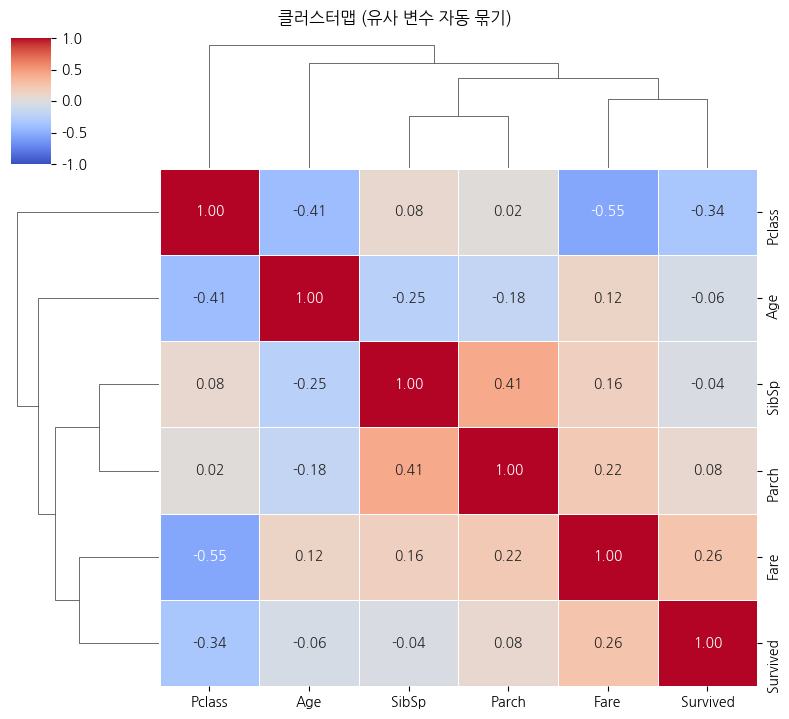

In [44]:
#clustermap: 히트맵 + 계층 클러스터링으로 비슷한 변수 자동 그룹화
g=sns.clustermap(corr_matrix,
                 annot=True,
                 fmt='.2f',
                 cmap='coolwarm', #음수=파랑,양수=빨강
                 vmin=-1, vmax=1, #상관계수는 항상 -1에서 1 사이의 값, 색상 범위
                 figsize=(8,7),
                 linewidths=0.5)
g.fig.suptitle('클러스터맵 (유사 변수 자동 묶기)', y=1.02)
plt.show()

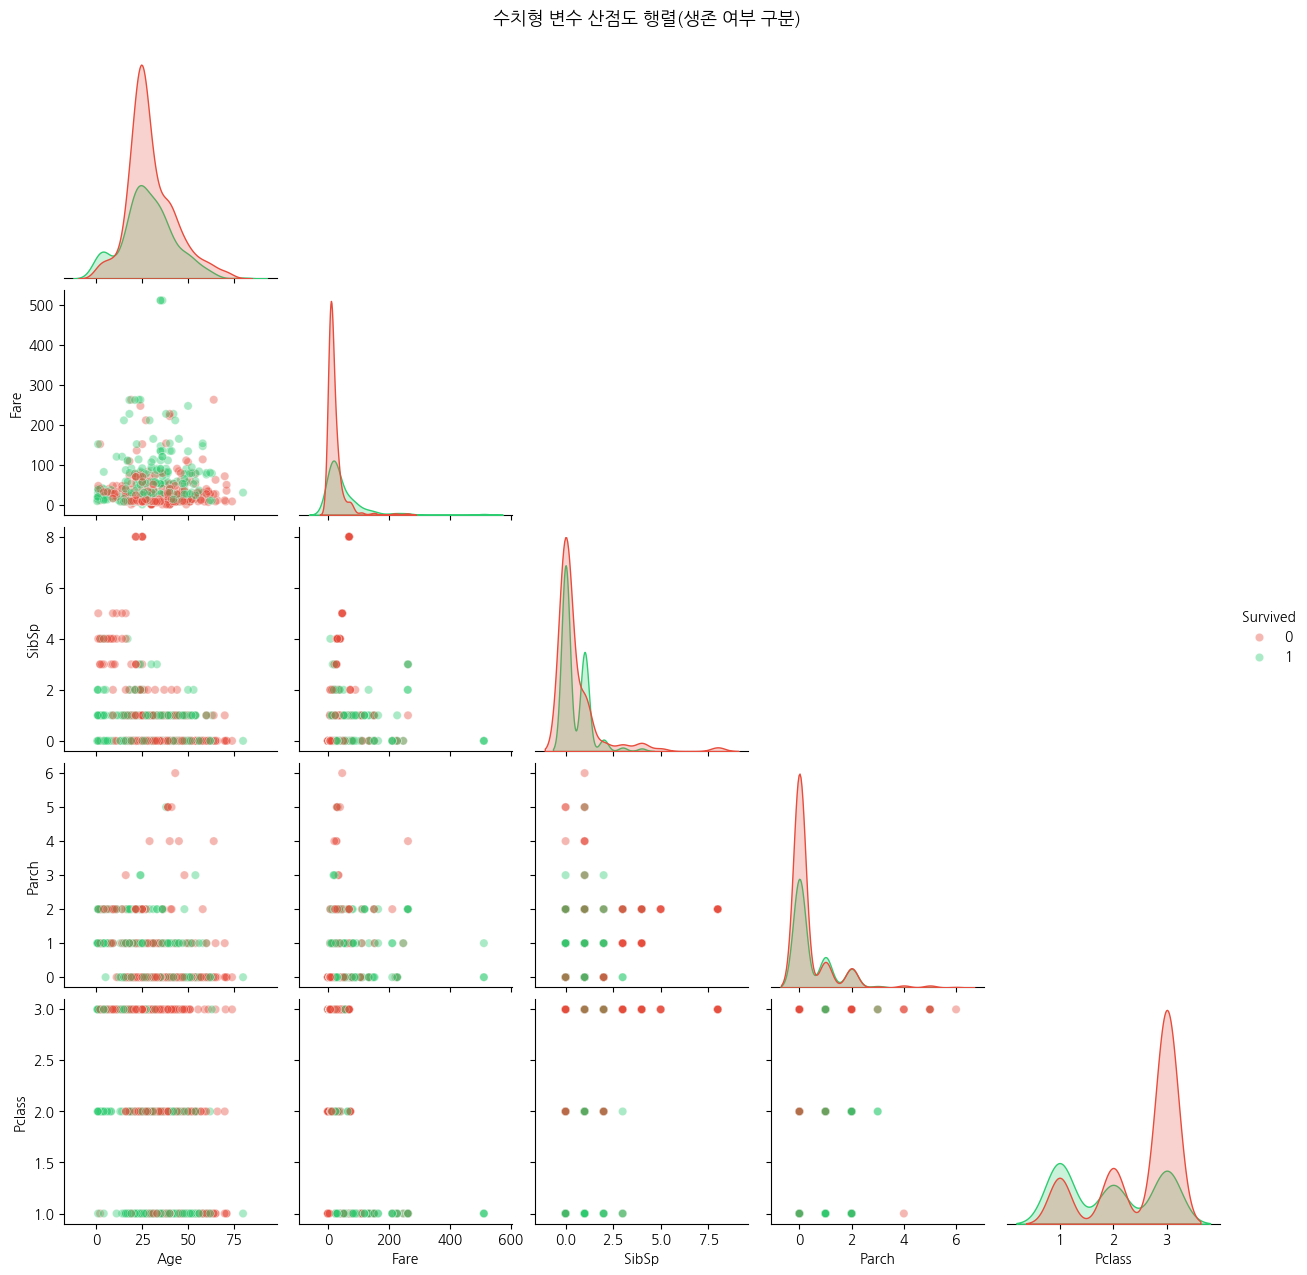

In [46]:
#산점도 행렬 - pairplot으로 상관관계 시각화
#pairplot: 변수 쌍별 산점도 + 대각선 분포 그래프

g=sns.pairplot(titanic_num, hue='Survived', palette={0:'#e74c3c', 1:'#2ecc71'},
               diag_kind='kde', #대각선:KDE 밀도 곡선
               plot_kws={'alpha':0.4},
               corner=True #하삼각형만 그리기
               )
g.fig.suptitle('수치형 변수 산점도 행렬(생존 여부 구분)',y=1.02, fontsize=13)
plt.show()

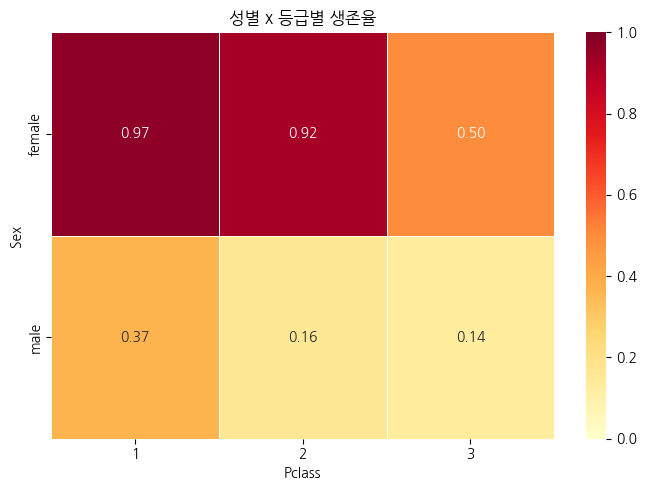

In [48]:
#pivot_table을 사용한 히트맵 그리기
pivot = titanic_clean.pivot_table(values='Survived',
                                  index='Sex', #행: 성별
                                  columns='Pclass', #열: 등급
                                  aggfunc='mean') #값: 생존율 평균

fig, axes=plt.subplots(figsize=(7,5))

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=axes, linewidths=0.5)
axes.set_title('성별 x 등급별 생존율')

plt.tight_layout()
plt.show()

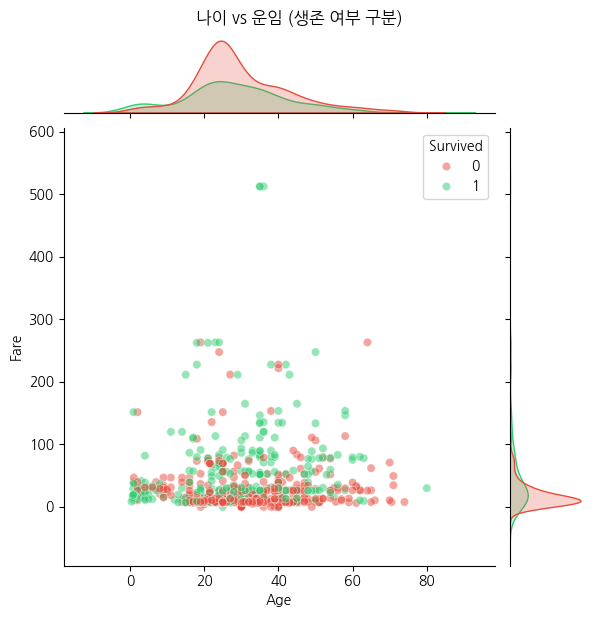

In [50]:
#jointplot: 산점도 + 양쪽 주변 분포 한 번에
g=sns.jointplot( data=titanic_clean, x='Age', y='Fare', hue='Survived', palette={0:'#e74c3c', 1:'#2ecc71'}, alpha=0.5, kind='scatter')
g.figure.suptitle('나이 vs 운임 (생존 여부 구분)', y=1.02)
plt.show()

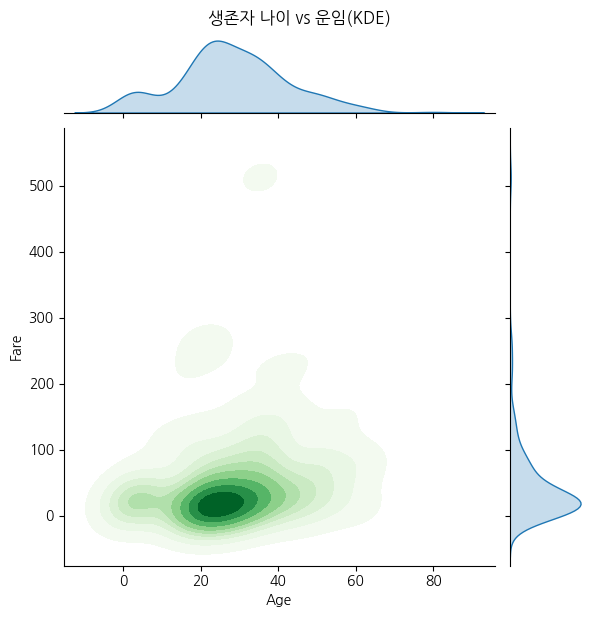

In [60]:
#jointplot kind='kde': 등고선 형태로 밀도 표현
g=sns.jointplot(data=titanic_clean[titanic_clean['Survived']==1],x='Age',y='Fare', kind='kde', fill=True, cmap='Greens')
g.figure.suptitle('생존자 나이 vs 운임(KDE)', y=1.02)
plt.show()

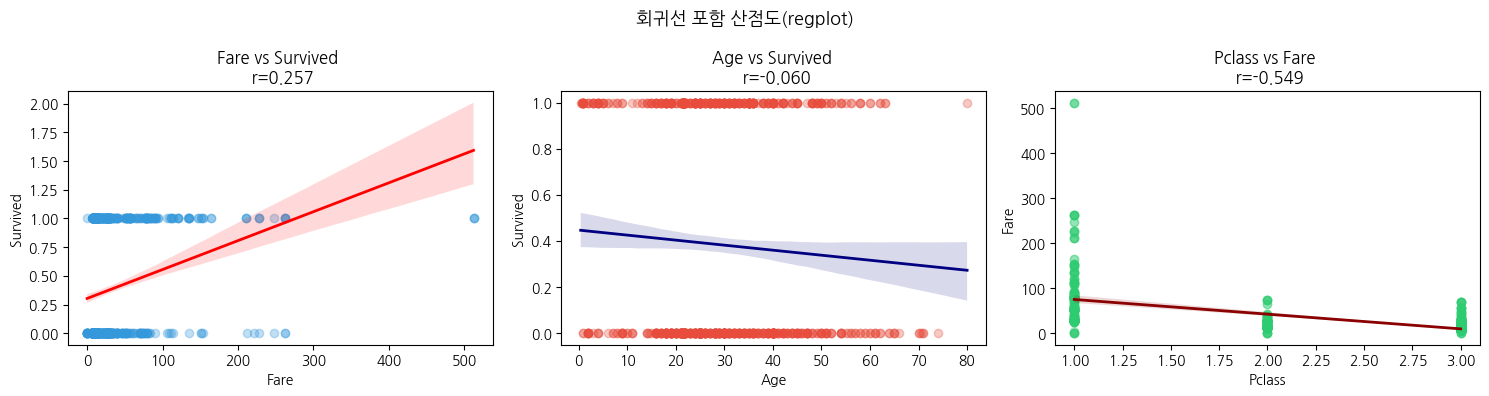

In [58]:
#regplot으로 두 변수 상관 확인
fig, axes = plt.subplots(1,3,figsize=(15,4))
fig.suptitle('회귀선 포함 산점도(regplot)', fontsize=13)

#Fare와 Survived
sns.regplot(data=titanic_clean, x='Fare', y='Survived', scatter_kws={'alpha':0.3, 'color':'#3498db'}, line_kws={'color':'red', 'linewidth':2},ax=axes[0])
axes[0].set_title(f'Fare vs Survived \n r={titanic_clean["Fare"].corr(titanic_clean["Survived"]):.3f}')
#제목에 상관계수 r값 직접 표시
#피어슨 상관계수 (Pearson correlation coefficient) r은 두 연속형 변수 간의 선령적인 관계의 강도와 방향을 나타냄
#r이 1에 가까울수록: 강한 양의 선형 관계 (한 변수가 증가하면 다른 변수도 증가)
#r이 -1에 가까울수록: 강한 음의 선령 관계 (한 변수가 증가하면 다른 변수는 감소)
#r이 0에 가까울수록: 선형 관계가 거의 없음 (변수들이 서로 독립적)

#Age와 Survived
sns.regplot(data=titanic_clean, x='Age', y='Survived', scatter_kws={'alpha':0.3, 'color':'#e74c3c'}, line_kws={'color':'navy', 'linewidth':2},ax=axes[1])
axes[1].set_title(f'Age vs Survived \n r={titanic_clean["Age"].corr(titanic_clean["Survived"]):.3f}')

#Pclass와 Fare
sns.regplot(data=titanic_clean, x='Pclass', y='Fare', scatter_kws={'alpha':0.3, 'color':'#2ecc71'}, line_kws={'color':'darkred', 'linewidth':2},ax=axes[2])
axes[2].set_title(f'Pclass vs Fare \n r={titanic_clean["Pclass"].corr(titanic_clean["Fare"]):.3f}')
#점들이 회귀선 주위에 비교적 밀집되어 있어 관계가 뚜렷함

plt.tight_layout()
plt.show()